# Лабораторна робота №6  

- 3 моделі: `Var03`, `Var15`, `Var18`;
- розбиття даних на `train/test = 75/25`;

In [1]:
import os
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display, Markdown
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [17]:
np.seterr(over="ignore", invalid="ignore", divide="ignore")

DATA_FILE = "DataRegression.xlsx"
ANIM_DIR = Path("animations") 
ANIM_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.25
N_ITER = 10_000
POP_SIZE = 50
SNAPSHOT_EVERY = 250
ANIMATION_FPS = 5

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Функціональні залежності

Обрані моделі 3, 15, 18

In [ ]:
def safe_exp(z):
    return np.exp(np.clip(z, -700, 700))


def model_var03(x, b):
    return (
        b[0] * safe_exp(-b[1] * x)
        + b[2] * safe_exp(-b[3] * x)
        + b[4] * safe_exp(-b[5] * x)
    )


def model_var15(x, b):
    return b[0] / (1.0 + safe_exp(b[1] - b[2] * x))


def model_var18(x, b):
    base = np.maximum(b[1] + x, 1e-12)
    b3 = np.maximum(float(b[2]), 1e-6)
    exponent = np.clip((-1.0 / b3) * np.log(base), -700, 700)
    return b[0] * np.exp(exponent)


VARIANTS = {
    "Var03": {
        "name": "Варіант 3: сума трьох експонент",
        "model": model_var03,
        "bounds": [(0, 1), (0, 1), (0, 1), (0, 10), (0, 10), (0, 10)],
        "formula": "y = b1 exp(-b2 x) + b3 exp(-b4 x) + b5 exp(-b6 x)",
    },
    "Var15": {
        "name": "Варіант 15: логістична модель",
        "model": model_var15,
        "bounds": [(50, 100), (1, 10), (0, 1)],
        "formula": "y = b1 / (1 + exp(b2 - b3 x))",
    },
    "Var18": {
        "name": "Варіант 18: степенева модель",
        "model": model_var18,
        "bounds": [(-10000, -1000), (1, 100), (1e-6, 1)],
        "formula": "y = b1 (b2 + x)^(-1/b3)",
    },
}

for key, cfg in VARIANTS.items():
    print(f"{key}: {cfg['formula']}")


Var03: y = b1 exp(-b2 x) + b3 exp(-b4 x) + b5 exp(-b6 x)
Var15: y = b1 / (1 + exp(b2 - b3 x))
Var18: y = b1 (b2 + x)^(-1/b3)


## 2. Завантаження даних і розбиття train/test


In [4]:

def load_variant_data(sheet_name, data_file=DATA_FILE):
    df = pd.read_excel(data_file, sheet_name=sheet_name)
    df = df.dropna().copy()
    y = df.iloc[:, 0].to_numpy(dtype=float)
    x = df.iloc[:, 1].to_numpy(dtype=float)
    return df, x, y


def prepare_train_test(sheet_name):
    df, x, y = load_variant_data(sheet_name)
    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
    )
    return {
        "df": df,
        "x_train": x_train,
        "x_test": x_test,
        "y_train": y_train,
        "y_test": y_test,
    }


datasets = {sheet: prepare_train_test(sheet) for sheet in VARIANTS}

for sheet, data in datasets.items():
    display(Markdown(f"### {sheet}"))
    display(data["df"].head())
    print(
        f"Усього: {len(data['df'])}; train: {len(data['x_train'])}; test: {len(data['x_test'])}"
    )


### Var03

,y,x
0,2.5134,0.00
1,2.0443,0.05
2,1.6684,0.10
3,1.3664,0.15
4,1.1232,0.20


Усього: 24; train: 18; test: 6


### Var15

,y,x
0,8.93,9
1,10.80,14
2,18.59,21
3,22.33,28
4,39.35,42


Усього: 9; train: 6; test: 3


### Var18

,y,x
0,-34.834702,7.447168
1,-34.393200,8.102586
2,-34.152901,8.452547
3,-33.979099,8.711278
4,-33.845901,8.916774


Усього: 154; train: 115; test: 39


## 3. Допоміжні функції: MSE, метрики


In [5]:

def finite_mse(y_true, y_pred):
    if not np.all(np.isfinite(y_pred)):
        return 1e300
    value = np.mean((y_true - y_pred) ** 2)
    return float(value) if np.isfinite(value) else 1e300


def make_objective(model, x, y):
    def objective(b):
        b = np.asarray(b, dtype=float)
        return finite_mse(y, model(x, b))
    return objective


def calculate_metrics(model, b, x_train, y_train, x_test, y_test):
    pred_train = model(x_train, b)
    pred_test = model(x_test, b)
    return {
        "train_mse": mean_squared_error(y_train, pred_train),
        "test_mse": mean_squared_error(y_test, pred_test),
        "train_rmse": math.sqrt(mean_squared_error(y_train, pred_train)),
        "test_rmse": math.sqrt(mean_squared_error(y_test, pred_test)),
        "train_mae": mean_absolute_error(y_train, pred_train),
        "test_mae": mean_absolute_error(y_test, pred_test),
        "train_r2": r2_score(y_train, pred_train),
        "test_r2": r2_score(y_test, pred_test),
    }


## 4. Метод диференціальної еволюції
 
На кожній ітерації зберігається найкращий результат на `train` і значення тієї ж моделі на `test`, щоб потім побудувати один графік збіжності Train/Test.


In [6]:
def differential_evolution_custom(
    objective_train,
    objective_test,
    bounds,
    n_iter=N_ITER,
    pop_size=POP_SIZE,
    F=0.8,
    CR=0.9,
    seed=RANDOM_STATE,
    snapshot_every=SNAPSHOT_EVERY,
):
    rng = np.random.default_rng(seed)
    bounds = np.array(bounds, dtype=float)
    lo, hi = bounds[:, 0], bounds[:, 1]
    dim = len(bounds)
    pop_size = max(pop_size, dim * 8)

    population = rng.uniform(lo, hi, size=(pop_size, dim))
    scores = np.array([objective_train(ind) for ind in population])

    best_idx = int(np.argmin(scores))
    best = population[best_idx].copy()
    best_train = float(scores[best_idx])

    train_history = []
    test_history = []
    snapshots = []

    for iteration in range(1, n_iter + 1):
        for i in range(pop_size):
            candidates = np.delete(np.arange(pop_size), i)
            a, b, c = rng.choice(candidates, 3, replace=False)

            mutant = population[a] + F * (population[b] - population[c])
            mutant = np.clip(mutant, lo, hi)

            cross_mask = rng.random(dim) < CR
            cross_mask[rng.integers(0, dim)] = True
            trial = np.where(cross_mask, mutant, population[i])

            trial_score = objective_train(trial)
            if trial_score <= scores[i]:
                population[i] = trial
                scores[i] = trial_score

                if trial_score < best_train:
                    best = trial.copy()
                    best_train = float(trial_score)

        train_history.append(best_train)
        test_history.append(objective_test(best))

        if iteration == 1 or iteration % snapshot_every == 0 or iteration == n_iter:
            snapshots.append((iteration, best.copy(), best_train, objective_test(best)))

    return {
        "best": best,
        "best_train": best_train,
        "best_test": objective_test(best),
        "train_history": np.array(train_history),
        "test_history": np.array(test_history),
        "snapshots": snapshots,
    }


## 5. Алгоритм оптимізації роєм частинок


In [7]:
def pso_custom(
    objective_train,
    objective_test,
    bounds,
    n_iter=N_ITER,
    n_particles=POP_SIZE,
    w=0.72,
    c1=1.49,
    c2=1.49,
    seed=RANDOM_STATE,
    snapshot_every=SNAPSHOT_EVERY,
):
    rng = np.random.default_rng(seed)
    bounds = np.array(bounds, dtype=float)
    lo, hi = bounds[:, 0], bounds[:, 1]
    dim = len(bounds)
    span = hi - lo

    x = rng.uniform(lo, hi, size=(n_particles, dim))
    v = rng.uniform(-span, span, size=(n_particles, dim)) * 0.1

    pbest = x.copy()
    pbest_scores = np.array([objective_train(ind) for ind in x])

    g_idx = int(np.argmin(pbest_scores))
    gbest = pbest[g_idx].copy()
    gbest_score = float(pbest_scores[g_idx])

    train_history = []
    test_history = []
    snapshots = []

    for iteration in range(1, n_iter + 1):
        r1 = rng.random((n_particles, dim))
        r2 = rng.random((n_particles, dim))

        v = w * v + c1 * r1 * (pbest - x) + c2 * r2 * (gbest - x)
        v = np.clip(v, -span, span)
        x = x + v

        below = x < lo
        above = x > hi
        x = np.clip(x, lo, hi)
        v[below | above] *= -0.5

        scores = np.array([objective_train(ind) for ind in x])
        improved = scores < pbest_scores
        pbest[improved] = x[improved]
        pbest_scores[improved] = scores[improved]

        g_idx = int(np.argmin(pbest_scores))
        if pbest_scores[g_idx] < gbest_score:
            gbest = pbest[g_idx].copy()
            gbest_score = float(pbest_scores[g_idx])

        train_history.append(gbest_score)
        test_history.append(objective_test(gbest))

        if iteration == 1 or iteration % snapshot_every == 0 or iteration == n_iter:
            snapshots.append((iteration, gbest.copy(), gbest_score, objective_test(gbest)))

    return {
        "best": gbest,
        "best_train": gbest_score,
        "best_test": objective_test(gbest),
        "train_history": np.array(train_history),
        "test_history": np.array(test_history),
        "snapshots": snapshots,
    }


## 6. Запуск оптимізації для всіх трьох моделей

Цей блок запускає обидва алгоритми для `Var03`, `Var15`, `Var18`.  
Після виконання буде створена таблиця з параметрами й метриками.


In [8]:
results = []
run_outputs = {}

algorithms = {
    "DE": differential_evolution_custom,
    "PSO": pso_custom
}

for sheet, cfg in VARIANTS.items():
    data = datasets[sheet]

    model = cfg["model"]
    bounds = cfg["bounds"]
    formula = cfg["formula"]

    x_train = data["x_train"]
    y_train = data["y_train"]
    x_test = data["x_test"]
    y_test = data["y_test"]

    objective_train = make_objective(model, x_train, y_train)
    objective_test = make_objective(model, x_test, y_test)

    for alg_name, alg_func in algorithms.items():

        start_time = time.time()

        output = alg_func(
            objective_train=objective_train,
            objective_test=objective_test,
            bounds=bounds,
            seed=RANDOM_STATE
        )

        elapsed = time.time() - start_time

        run_outputs[(sheet, alg_name)] = output

        metrics = calculate_metrics(
            model,
            output["best"],
            x_train,
            y_train,
            x_test,
            y_test
        )

        results.append({
            "variant": sheet,
            "method": alg_name,
            "formula": formula,
            "params": np.array2string(output["best"], precision=3, separator=", "),
            "time": round(elapsed, 3),
            "train_mse": round(metrics["train_mse"], 3),
            "test_mse": round(metrics["test_mse"], 3),
            "train_rmse": round(metrics["train_rmse"], 3),
            "test_rmse": round(metrics["test_rmse"], 3),
            "train_mae": round(metrics["train_mae"], 3),
            "test_mae": round(metrics["test_mae"], 3),
            "train_r2": round(metrics["train_r2"], 3),
            "test_r2": round(metrics["test_r2"], 3)
        })

summary = pd.DataFrame(results)
display(summary)

summary_sorted = summary.sort_values(["variant", "test_mse"]).reset_index(drop=True)
display(summary_sorted)

best_by_variant = summary_sorted.loc[
    summary_sorted.groupby("variant")["test_mse"].idxmin()
].reset_index(drop=True)

display(best_by_variant)

,variant,method,formula,params,time,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,Var03,DE,y = b1 exp(-b2 x) + b3 exp(-b4 x) + b5 exp(-b6 x),"[0.111, 1. , 1. , 5.527, 1.405, 3.472]",98.854,0.000,0.000,0.000,0.001,0.000,0.000,1.000,1.000
1,Var03,PSO,y = b1 exp(-b2 x) + b3 exp(-b4 x) + b5 exp(-b6 x),"[0.122, 1. , 0.513, 6.499, 1.883, 3.782]",39.689,0.000,0.000,0.000,0.002,0.000,0.001,1.000,1.000
2,Var15,DE,y = b1 / (1 + exp(b2 - b3 x)),"[7.279e+01, 2.574e+00, 6.592e-02]",73.355,1.234,0.343,1.111,0.586,0.979,0.502,0.997,0.999
3,Var15,PSO,y = b1 / (1 + exp(b2 - b3 x)),"[7.279e+01, 2.574e+00, 6.592e-02]",24.446,1.234,0.343,1.111,0.586,0.979,0.502,0.997,0.999
4,Var18,DE,y = b1 (b2 + x)^(-1/b3),"[-2.386e+03, 4.615e+01, 9.419e-01]",83.290,0.000,0.000,0.002,0.001,0.001,0.001,1.000,1.000
5,Var18,PSO,y = b1 (b2 + x)^(-1/b3),"[-4.338e+03, 5.240e+01, 8.481e-01]",30.216,0.000,0.000,0.002,0.001,0.001,0.001,1.000,1.000


,variant,method,formula,params,time,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,Var03,DE,y = b1 exp(-b2 x) + b3 exp(-b4 x) + b5 exp(-b6 x),"[0.111, 1. , 1. , 5.527, 1.405, 3.472]",98.854,0.000,0.000,0.000,0.001,0.000,0.000,1.000,1.000
1,Var03,PSO,y = b1 exp(-b2 x) + b3 exp(-b4 x) + b5 exp(-b6 x),"[0.122, 1. , 0.513, 6.499, 1.883, 3.782]",39.689,0.000,0.000,0.000,0.002,0.000,0.001,1.000,1.000
2,Var15,DE,y = b1 / (1 + exp(b2 - b3 x)),"[7.279e+01, 2.574e+00, 6.592e-02]",73.355,1.234,0.343,1.111,0.586,0.979,0.502,0.997,0.999
3,Var15,PSO,y = b1 / (1 + exp(b2 - b3 x)),"[7.279e+01, 2.574e+00, 6.592e-02]",24.446,1.234,0.343,1.111,0.586,0.979,0.502,0.997,0.999
4,Var18,DE,y = b1 (b2 + x)^(-1/b3),"[-2.386e+03, 4.615e+01, 9.419e-01]",83.290,0.000,0.000,0.002,0.001,0.001,0.001,1.000,1.000
5,Var18,PSO,y = b1 (b2 + x)^(-1/b3),"[-4.338e+03, 5.240e+01, 8.481e-01]",30.216,0.000,0.000,0.002,0.001,0.001,0.001,1.000,1.000


,variant,method,formula,params,time,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,Var03,DE,y = b1 exp(-b2 x) + b3 exp(-b4 x) + b5 exp(-b6 x),"[0.111, 1. , 1. , 5.527, 1.405, 3.472]",98.854,0.000,0.000,0.000,0.001,0.000,0.000,1.000,1.000
1,Var15,DE,y = b1 / (1 + exp(b2 - b3 x)),"[7.279e+01, 2.574e+00, 6.592e-02]",73.355,1.234,0.343,1.111,0.586,0.979,0.502,0.997,0.999
2,Var18,DE,y = b1 (b2 + x)^(-1/b3),"[-2.386e+03, 4.615e+01, 9.419e-01]",83.290,0.000,0.000,0.002,0.001,0.001,0.001,1.000,1.000


## 7. Графіки збіжності 


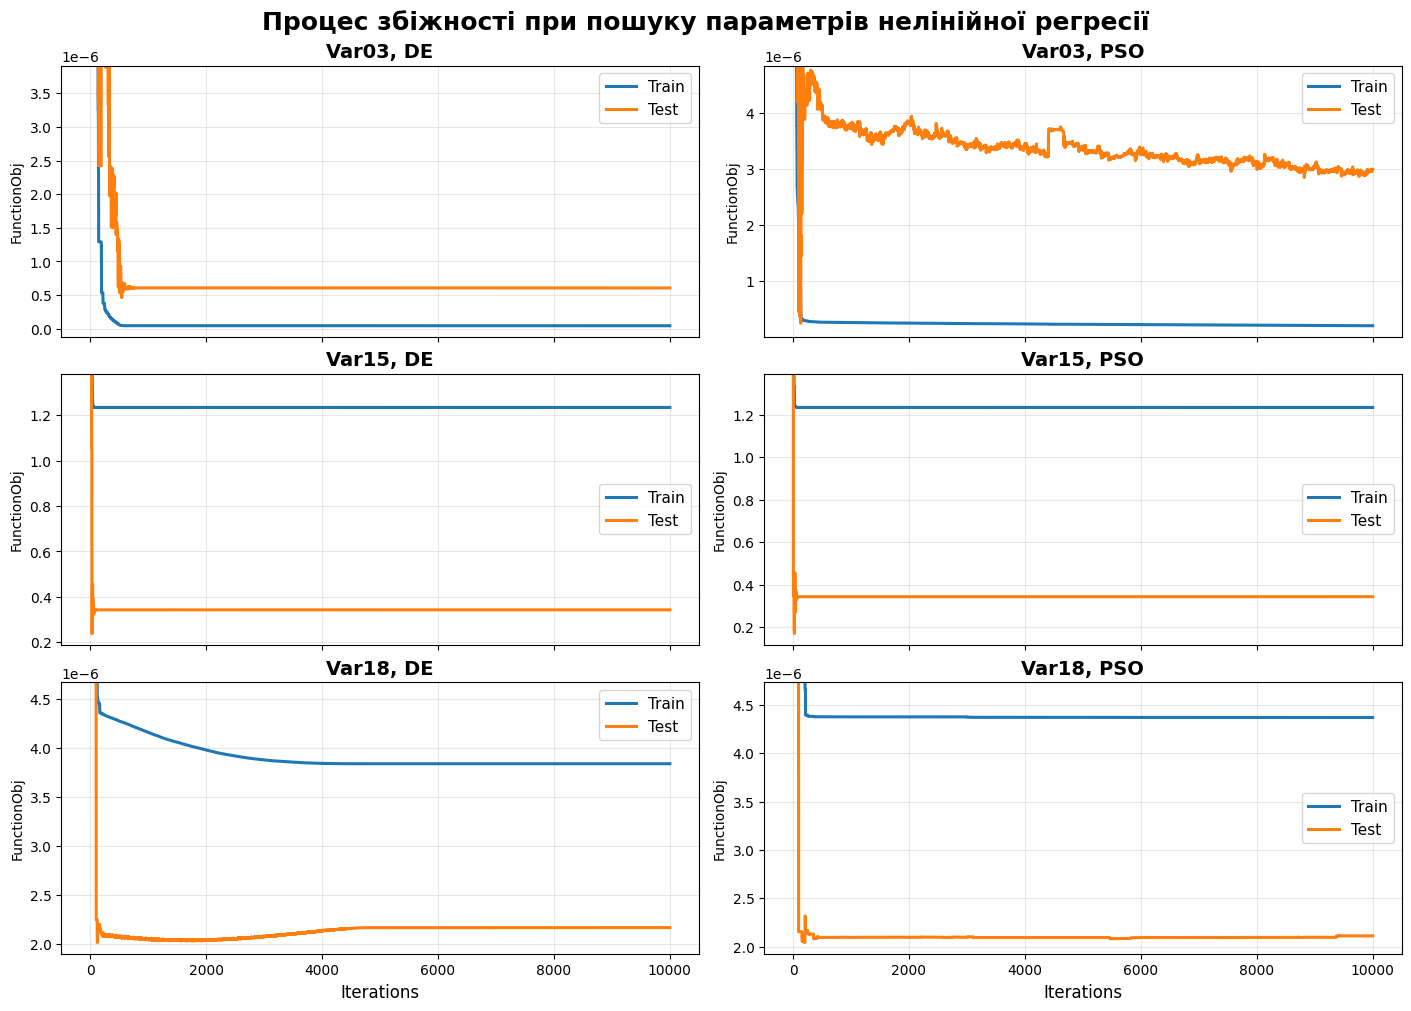

In [ ]:
def plot_all_convergence_grid(run_outputs):
    sheets = list(VARIANTS.keys())
    algorithms = ["DE", "PSO"]

    fig, axes = plt.subplots(
        nrows=len(sheets),
        ncols=len(algorithms),
        figsize=(14, 10),
        sharex=True,
        constrained_layout=True,
    )

    for row, sheet in enumerate(sheets):
        for col, alg_name in enumerate(algorithms):
            ax = axes[row, col]
            output = run_outputs[(sheet, alg_name)]
            iterations = np.arange(1, len(output["train_history"]) + 1)

            ax.plot(iterations, output["train_history"], linewidth=2.2, label="Train")
            ax.plot(iterations, output["test_history"], linewidth=2.2, label="Test")
            ax.set_title(f"{sheet}, {alg_name}", fontsize=14, fontweight="bold")
            ax.set_ylabel("FunctionObj")
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=11)

    
            values = np.r_[output["train_history"], output["test_history"]]
            high = np.nanpercentile(values[np.isfinite(values)], 98)
            low = np.nanmin(values[np.isfinite(values)])
            if high > low:
                ax.set_ylim(low - 0.05 * (high - low), high + 0.15 * (high - low))

    for ax in axes[-1, :]:
        ax.set_xlabel("Iterations", fontsize=12)

    fig.suptitle("Процес збіжності при пошуку параметрів нелінійної регресії", fontsize=18, fontweight="bold")
    plt.show()


plot_all_convergence_grid(run_outputs)

## 8. Графіки прогнозу


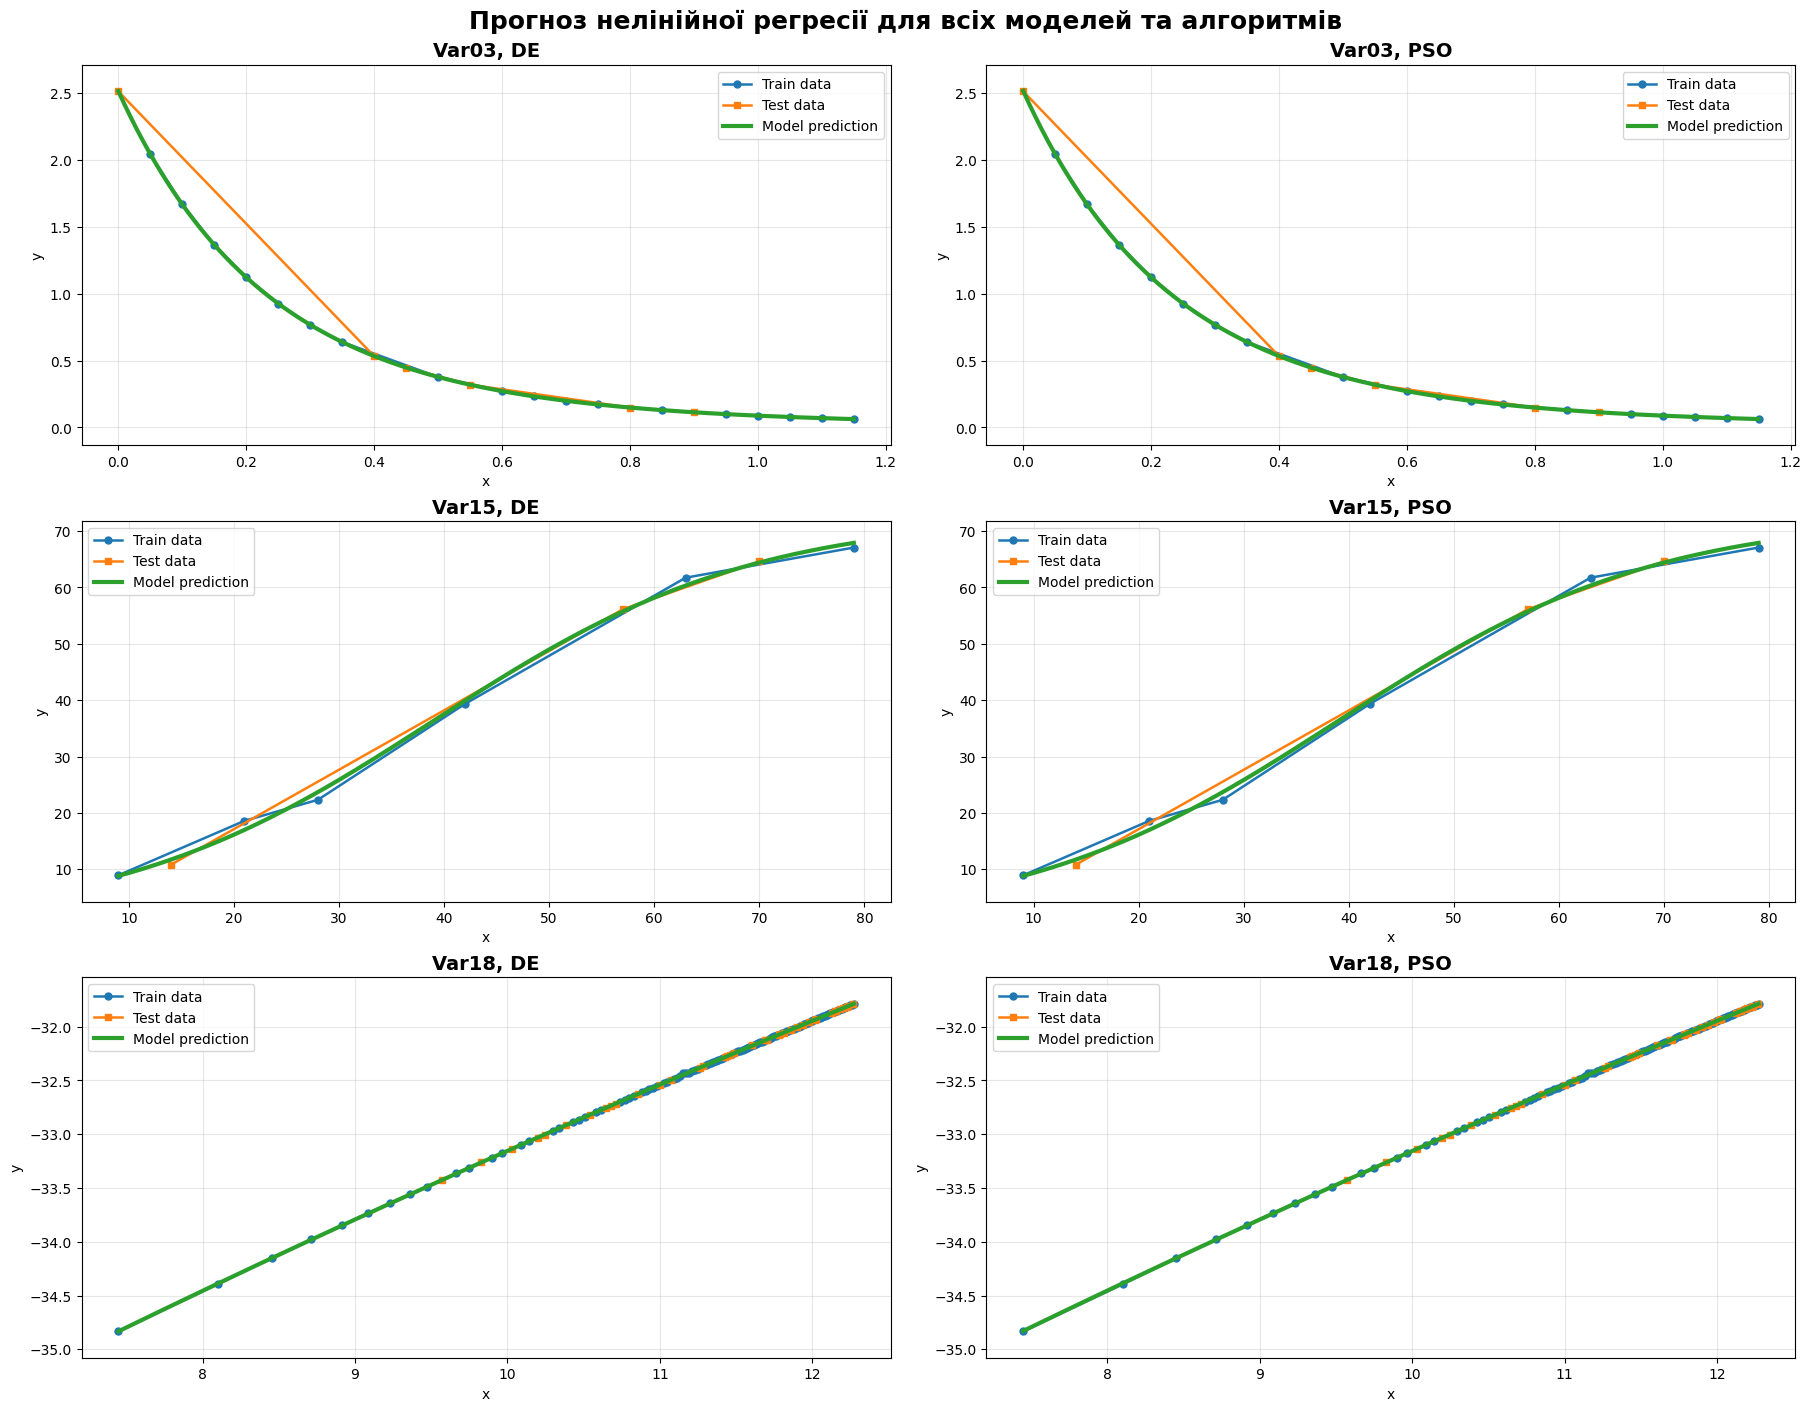

In [10]:
def plot_all_prediction_grid(run_outputs):
    sheets = list(VARIANTS.keys())
    algorithms = ["DE", "PSO"]

    fig, axes = plt.subplots(
        nrows=len(sheets),
        ncols=len(algorithms),
        figsize=(18, 14),
        constrained_layout=True,
    )

    for row, sheet in enumerate(sheets):
        cfg = VARIANTS[sheet]
        data = datasets[sheet]
        model = cfg["model"]

        x_train = data["x_train"]
        y_train = data["y_train"]
        x_test = data["x_test"]
        y_test = data["y_test"]

        train_order = np.argsort(x_train)
        test_order = np.argsort(x_test)

        x_all = np.concatenate([x_train, x_test])
        y_all = np.concatenate([y_train, y_test])
        x_grid = np.linspace(np.min(x_all), np.max(x_all), 700)

        for col, alg_name in enumerate(algorithms):
            ax = axes[row, col]
            output = run_outputs[(sheet, alg_name)]
            b = output["best"]
            y_grid = model(x_grid, b)

            ax.plot(x_train[train_order], y_train[train_order], "o-", linewidth=1.8, markersize=5, label="Train data")
            ax.plot(x_test[test_order], y_test[test_order], "s-", linewidth=1.8, markersize=5, label="Test data")
            ax.plot(x_grid, y_grid, linewidth=3.0, label="Model prediction")
            ax.set_title(f"{sheet}, {alg_name}", fontsize=14, fontweight="bold")
            ax.set_xlabel("x")
            ax.set_ylabel("y")
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=10)

            y_margin = 0.08 * (float(np.max(y_all)) - float(np.min(y_all))) if np.max(y_all) > np.min(y_all) else 1
            ax.set_ylim(float(np.min(y_all)) - y_margin, float(np.max(y_all)) + y_margin)

    fig.suptitle("Прогноз нелінійної регресії для всіх моделей та алгоритмів", fontsize=18, fontweight="bold")
    plt.show()


plot_all_prediction_grid(run_outputs)

## 9. Анімації


In [20]:
def _latest_snapshot_before_or_at(output, frame_iteration):
    snapshots = output["snapshots"]
    latest = snapshots[0]
    for snap in snapshots:
        if snap[0] <= frame_iteration:
            latest = snap
        else:
            break
    return latest


def save_grouped_variant_animation(sheet):
    algorithms = ["DE", "PSO"]
    cfg = VARIANTS[sheet]
    data = datasets[sheet]
    model = cfg["model"]

    x_train = data["x_train"]
    y_train = data["y_train"]
    x_test = data["x_test"]
    y_test = data["y_test"]

    train_order = np.argsort(x_train)
    test_order = np.argsort(x_test)
    x_all = np.concatenate([x_train, x_test])
    y_all = np.concatenate([y_train, y_test])
    x_grid = np.linspace(np.min(x_all), np.max(x_all), 700)

    max_iter = max(len(run_outputs[(sheet, alg)]["train_history"]) for alg in algorithms)
    frames = list(range(1, max_iter + 1, SNAPSHOT_EVERY))
    if frames[-1] != max_iter:
        frames.append(max_iter)

    fig, axes = plt.subplots(2, 2, figsize=(17, 12), constrained_layout=True)
    fig.suptitle(f"Групова анімація для {sheet}: DE та PSO", fontsize=18, fontweight="bold")

    lines = {}
    pred_lines = {}
    texts = {}

    for col, alg_name in enumerate(algorithms):
        output = run_outputs[(sheet, alg_name)]
        train_history = output["train_history"]
        test_history = output["test_history"]

        ax_conv = axes[0, col]
        ax_conv.set_title(f"{alg_name}: збіжність", fontsize=14, fontweight="bold")



        ax_conv.set_xlim(1, len(train_history))

        all_history = np.array(train_history + test_history)
        all_history = all_history[np.isfinite(all_history)]

        y_min = all_history.min()
        y_max = all_history.max()

        padding = (y_max - y_min) * 0.1

        if padding == 0:
            padding = abs(y_max) * 0.1

        if padding == 0:
            padding = 1

        ax_conv.set_ylim(y_min - padding, y_max + padding)

        ax_conv.set_xlabel("Iterations")
        ax_conv.set_ylabel("FunctionObj")




        ax_conv.grid(True, alpha=0.3)
        line_train, = ax_conv.plot([], [], linewidth=2.2, label="Train")
        line_test, = ax_conv.plot([], [], linewidth=2.2, label="Test")
        text_conv = ax_conv.text(0.03, 0.92, "", transform=ax_conv.transAxes, fontsize=10, va="top")
        ax_conv.legend(fontsize=10)
        lines[alg_name] = (line_train, line_test)
        texts[(alg_name, "conv")] = text_conv

        ax_pred = axes[1, col]
        ax_pred.set_title(f"{alg_name}: прогноз", fontsize=14, fontweight="bold")
        ax_pred.plot(x_train[train_order], y_train[train_order], "o-", linewidth=1.6, markersize=4, label="Train data")
        ax_pred.plot(x_test[test_order], y_test[test_order], "s-", linewidth=1.6, markersize=4, label="Test data")
        pred_line, = ax_pred.plot([], [], linewidth=3.0, label="Model prediction")
        text_pred = ax_pred.text(0.03, 0.92, "", transform=ax_pred.transAxes, fontsize=10, va="top")
        ax_pred.set_xlim(float(np.min(x_all)), float(np.max(x_all)))
        y_margin = 0.08 * (float(np.max(y_all)) - float(np.min(y_all))) if np.max(y_all) > np.min(y_all) else 1
        ax_pred.set_ylim(float(np.min(y_all)) - y_margin, float(np.max(y_all)) + y_margin)
        ax_pred.set_xlabel("x")
        ax_pred.set_ylabel("y")
        ax_pred.grid(True, alpha=0.3)
        ax_pred.legend(fontsize=10)
        pred_lines[alg_name] = pred_line
        texts[(alg_name, "pred")] = text_pred

    def update(frame_iteration):
        artists = []
        for alg_name in algorithms:
            output = run_outputs[(sheet, alg_name)]
            train_history = output["train_history"]
            test_history = output["test_history"]
            frame = min(frame_iteration, len(train_history))
            xs = np.arange(1, frame + 1)

            line_train, line_test = lines[alg_name]
            line_train.set_data(xs, train_history[:frame])
            line_test.set_data(xs, test_history[:frame])

            iteration, b, train_score, test_score = _latest_snapshot_before_or_at(output, frame)
            pred_lines[alg_name].set_data(x_grid, model(x_grid, b))

            texts[(alg_name, "conv")].set_text(
                f"Iteration: {frame}\nTrain: {train_history[frame-1]:.6g}\nTest: {test_history[frame-1]:.6g}"
            )
            texts[(alg_name, "pred")].set_text(
                f"Snapshot: {iteration}\nTrain: {train_score:.6g}\nTest: {test_score:.6g}"
            )
            artists.extend([line_train, line_test, pred_lines[alg_name], texts[(alg_name, "conv")], texts[(alg_name, "pred")]])
        return artists

    anim = FuncAnimation(fig, update, frames=frames, interval=300, blit=False)
    path = ANIM_DIR / f"{sheet}_DE_PSO.gif"
    anim.save(path, writer=PillowWriter(fps=ANIMATION_FPS))
    plt.close(fig)
    return path



animation_paths = []

for sheet in VARIANTS.keys():
    save_grouped_variant_animation(sheet)

## 10. Порівняння результатів


In [12]:
summary_sorted = summary.sort_values(["variant", "test_mse"]).reset_index(drop=True)

best_by_variant = summary_sorted.loc[
    summary_sorted.groupby("variant")["test_mse"].idxmin()
].reset_index(drop=True)

display(Markdown("### Найкращий алгоритм для кожного варіанту за test MSE"))

display(best_by_variant[[
    "variant",
    "method",
    "test_mse",
    "test_rmse",
    "test_mae",
    "test_r2",
    "params"
]])

### Найкращий алгоритм для кожного варіанту за test MSE

,variant,method,test_mse,test_rmse,test_mae,test_r2,params
0,Var03,DE,0.000,0.001,0.000,1.000,"[0.111, 1. , 1. , 5.527, 1.405, 3.472]"
1,Var15,DE,0.343,0.586,0.502,0.999,"[7.279e+01, 2.574e+00, 6.592e-02]"
2,Var18,DE,0.000,0.001,0.001,1.000,"[-2.386e+03, 4.615e+01, 9.419e-01]"
